# Imports

In [1]:
!pip install pyreadstat

Looking in indexes: https://nexus.lan.huk-coburg.de/repository/pypi/simple
     - 617.7 kB 282.1 MB/s 0:00:00
    yapf (>='0.28') ; python_version < "3.6"
         ~^


In [2]:
import json
import pickle
import numpy as np
import pandas as pd
from pandas import MultiIndex, Int16Dtype
import time
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import functools
from datetime import datetime
import pyreadstat

import xgboost as xgb
import shap

from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.metrics import log_loss, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, accuracy_score, balanced_accuracy_score, f1_score, make_scorer, roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

from econml.metalearners import SLearner, TLearner, XLearner
from econml.dml import NonParamDML, LinearDML, SparseLinearDML, CausalForestDML, DML, KernelDML 
from econml.dml._rlearner import _RLearner
from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter
from econml.score import EnsembleCateEstimator
from econml.dr import DRLearner

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from econml.sklearn_extensions.model_selection import GridSearchCVList
from sklearn.base import clone

import lightgbm as lgbm

from sklearn.preprocessing import OneHotEncoder
import random

from functools import partialmethod
from itertools import chain

In [3]:
st = time.time()

In [4]:
# Aktuelles Datum und Zeit
now = datetime.now()

# Jahr und Tag des Jahres
year = now.year
day_of_year = now.timetuple().tm_yday

# Erstellen eines Timestamps
timestamp = f"{year}-{day_of_year:03d}"

print(f"Timestamp: {timestamp}")

Timestamp: 2025-142


# GLOBALS

In [5]:
TIMESTAMP = timestamp
FINAL_MODEL = 'ENSlearnS'
DATA_PATH = '/domino/edv/pvc-hf1kundehuk/ScoringdatensatzProduktiv/scoringdatensatz.sas7bdat'
TARGET_PATH = f"/domino/edv/pvc-hf1kundehuk/ScoringdatensatzProduktiv/kausalscore_ph.xpt"

# Code

In [6]:
def predict_in_batches(df, model, batch_size):
    predictions_list = []

    for i in range(0, len(df), batch_size):
        batch = df.iloc[i:i + batch_size]
        batch_predictions = model.const_marginal_effect(batch).flatten()
        predictions_list.append(batch_predictions)

    return list(chain(*predictions_list))

# Data Import

In [7]:
# Öffnen und lesen Sie die JSON-Datei
with open('column_datatypes_brief.json', 'rb') as file:
    content = file.read()     
    column_datatypes = json.loads(content.decode('utf-8'))

# 'data' ist jetzt ein Python-Dictionary, das die in der JSON-Datei enthaltenen Daten enthält
print(column_datatypes)

{'BDL': 'category', 'REGIO_GS_ENTFERNUNG': 'uint32', 'ALTERJ': 'uint8', 'GINT_KFZ_MIN_ERSTZULASSUNG': 'int16', 'WM_GESAMT': 'uint8', 'ALTERSGRUPPE': 'category', 'GINT_ZULASSUNG_DT': 'uint16', 'GINT_KUNDE_SEIT_J': 'int8', 'GINT_KFZ_JAHRESBEITRAG_KFZ': 'float16', 'REGIO_GS_BEREICH_FS': 'uint8', 'HUS_WM_GESAMT': 'uint8', 'GINT_KFZ_L_VERTRAG_M': 'int16', 'GINT_HUS_JAHRESBEITRAG_HUS': 'float16', 'GINT_KFZ_PS': 'uint16', 'LETZTE_VERMITTLER': 'category', 'MEINE_HUK_KUNDE': 'category', 'GINT_KFZ_KATEGORIE': 'category', 'GINT_KFZ_FZ_ALTER_A': 'uint8', 'GINT_KFZ_KUNDE_SEIT_J': 'int8', 'FAMILIENSTAND_FS': 'uint8', 'GINT_KFZ_JAHRESFAHRKILOMETER': 'uint8', 'SONST_UER_WM_GESAMT': 'uint8', 'GINT_LETZTE_ZUGANG_J': 'int8', 'STADT_TYP': 'category', 'PH_DICHTE': 'float16', 'GINT_HUS_HAUS_WOHNFLAECHE': 'uint16', 'HUS_ANGEBOT_L12MONATEIA3': 'uint8', 'FAHRZEUGWECHSEL_MO': 'int16', 'GINT_HUS_VSU': 'float32', 'GINT_HUS_KUNDE_SEIT_J': 'int8', 'KFZ_ANGEBOT_0_60': 'uint8', 'GINT_NK_J_VERTRAG_INKLHH': 'uint8', 'G

In [8]:
#Spalten hinzufügen, welche die Kunden eindeutig zuordenbar machen
column_datatypes['PARTNER_ID_V'] = 'int64'
column_datatypes['GESELLSCHAFT_FS'] = 'str'

print(column_datatypes)

{'BDL': 'category', 'REGIO_GS_ENTFERNUNG': 'uint32', 'ALTERJ': 'uint8', 'GINT_KFZ_MIN_ERSTZULASSUNG': 'int16', 'WM_GESAMT': 'uint8', 'ALTERSGRUPPE': 'category', 'GINT_ZULASSUNG_DT': 'uint16', 'GINT_KUNDE_SEIT_J': 'int8', 'GINT_KFZ_JAHRESBEITRAG_KFZ': 'float16', 'REGIO_GS_BEREICH_FS': 'uint8', 'HUS_WM_GESAMT': 'uint8', 'GINT_KFZ_L_VERTRAG_M': 'int16', 'GINT_HUS_JAHRESBEITRAG_HUS': 'float16', 'GINT_KFZ_PS': 'uint16', 'LETZTE_VERMITTLER': 'category', 'MEINE_HUK_KUNDE': 'category', 'GINT_KFZ_KATEGORIE': 'category', 'GINT_KFZ_FZ_ALTER_A': 'uint8', 'GINT_KFZ_KUNDE_SEIT_J': 'int8', 'FAMILIENSTAND_FS': 'uint8', 'GINT_KFZ_JAHRESFAHRKILOMETER': 'uint8', 'SONST_UER_WM_GESAMT': 'uint8', 'GINT_LETZTE_ZUGANG_J': 'int8', 'STADT_TYP': 'category', 'PH_DICHTE': 'float16', 'GINT_HUS_HAUS_WOHNFLAECHE': 'uint16', 'HUS_ANGEBOT_L12MONATEIA3': 'uint8', 'FAHRZEUGWECHSEL_MO': 'int16', 'GINT_HUS_VSU': 'float32', 'GINT_HUS_KUNDE_SEIT_J': 'int8', 'KFZ_ANGEBOT_0_60': 'uint8', 'GINT_NK_J_VERTRAG_INKLHH': 'uint8', 'G

In [9]:
# Öffnen Sie die Textdatei zum Lesen
with open('feature_order_brief.txt', 'rb') as file:     
    # Lesen Sie die Zeilen der Datei und erstellen Sie eine Liste    
    content = file.read()     
    decoded_content = content.decode('utf-8')     
    feature_order = decoded_content.split('\n')     
    feature_order = [feature for feature in feature_order if feature]

# Entfernen Sie eventuelle Zeilenumbrüche am Ende jeder Zeile
feature_order = [line.replace('\n', '') for line in feature_order] 

# Jetzt haben Sie eine Liste, in der jede Zeile der Datei ein Element ist
print(feature_order)

['BDL', 'REGIO_GS_ENTFERNUNG', 'ALTERJ', 'GINT_KFZ_MIN_ERSTZULASSUNG', 'WM_GESAMT', 'ALTERSGRUPPE', 'GINT_ZULASSUNG_DT', 'GINT_KUNDE_SEIT_J', 'GINT_KFZ_JAHRESBEITRAG_KFZ', 'REGIO_GS_BEREICH_FS', 'HUS_WM_GESAMT', 'GINT_KFZ_L_VERTRAG_M', 'GINT_HUS_JAHRESBEITRAG_HUS', 'GINT_KFZ_PS', 'LETZTE_VERMITTLER', 'MEINE_HUK_KUNDE', 'GINT_KFZ_KATEGORIE', 'GINT_KFZ_FZ_ALTER_A', 'GINT_KFZ_KUNDE_SEIT_J', 'FAMILIENSTAND_FS', 'GINT_KFZ_JAHRESFAHRKILOMETER', 'SONST_UER_WM_GESAMT', 'GINT_LETZTE_ZUGANG_J', 'STADT_TYP', 'PH_DICHTE', 'GINT_HUS_HAUS_WOHNFLAECHE', 'HUS_ANGEBOT_L12MONATEIA3', 'FAHRZEUGWECHSEL_MO', 'GINT_HUS_VSU', 'GINT_HUS_KUNDE_SEIT_J', 'KFZ_ANGEBOT_0_60', 'GINT_NK_J_VERTRAG_INKLHH', 'GINT_HUS_JAHRESBEITRAG_HUS_IHH', 'GINT_HUS_LETZTE_VERTR_ZUGANG', 'WG_ZU_DICHTE', 'HUS_ANGEBOT_L12MONATE_IHH', 'VERTRAEGE_GESAMT', 'PH_ANGEBOT_L12MONATE', 'HUS_WM_60', 'SPARTE_GESAMT_IHH', 'GINT_HUS_LETZTE_ZUGANG_J', 'ANZAHL_SPARTEN_8', 'HUS_ANGEBOT_0_36IA3', 'TAGE_UMZUG', 'HUS_ANGEBOT_L12MONATE', 'HRC_DICHTE', 'RO

In [10]:
# Öffnen und lesen Sie die JSON-Datei
with open('median_values_brief.json', 'rb') as file:     
    content = file.read()     
    median_values = json.loads(content.decode('utf-8'))

# 'data' ist jetzt ein Python-Dictionary, das die in der JSON-Datei enthaltenen Daten enthält
print(median_values)

{'REGIO_GS_ENTFERNUNG': 23055.0, 'ALTERJ': 46.0, 'GINT_KFZ_MIN_ERSTZULASSUNG': 19053.0, 'WM_GESAMT': 9.0, 'GINT_ZULASSUNG_DT': 22036.0, 'GINT_KUNDE_SEIT_J': 3.0, 'GINT_KFZ_JAHRESBEITRAG_KFZ': 464.0, 'REGIO_GS_BEREICH_FS': 20.0, 'HUS_WM_GESAMT': 4.0, 'GINT_KFZ_L_VERTRAG_M': 22.0, 'GINT_HUS_JAHRESBEITRAG_HUS': 0.0, 'GINT_KFZ_PS': 102.0, 'GINT_KFZ_FZ_ALTER_A': 8.0, 'GINT_KFZ_KUNDE_SEIT_J': 2.0, 'FAMILIENSTAND_FS': 2.0, 'GINT_KFZ_JAHRESFAHRKILOMETER': 15.0, 'SONST_UER_WM_GESAMT': 2.0, 'GINT_LETZTE_ZUGANG_J': 2.0, 'PH_DICHTE': 29.92, 'GINT_HUS_HAUS_WOHNFLAECHE': 0.0, 'HUS_ANGEBOT_L12MONATEIA3': 0.0, 'FAHRZEUGWECHSEL_MO': -1.0, 'GINT_HUS_VSU': 0.0, 'GINT_HUS_KUNDE_SEIT_J': -1.0, 'KFZ_ANGEBOT_0_60': 1.0, 'GINT_NK_J_VERTRAG_INKLHH': 4.0, 'GINT_HUS_JAHRESBEITRAG_HUS_IHH': 0.0, 'GINT_HUS_LETZTE_VERTR_ZUGANG': 0.0, 'WG_ZU_DICHTE': 0.4, 'HUS_ANGEBOT_L12MONATE_IHH': 0.0, 'VERTRAEGE_GESAMT': 1.0, 'PH_ANGEBOT_L12MONATE': 0.0, 'HUS_WM_60': 1.0, 'SPARTE_GESAMT_IHH': 1.0, 'GINT_HUS_LETZTE_ZUGANG_J': -1.

In [11]:
file = open("encoding_brief.obj",'rb')
encoding_brief = pickle.load(file)
file.close()

#GESELLSCHAFT_FS entfernen
encoding_brief.pop('GESELLSCHAFT_FS')

print(encoding_brief)

{'ALTERSGRUPPE': {'13 70-74J': 12, '12 65-69J': 11, '11 60-64J': 10, '14 75J': 13, '10 55-59J': 9, '09 50-54J': 8, '08 45-49J': 7, '05 30-34J': 4, '07 40-44J': 6, '06 35-39J': 5, '04 25-29J': 3, '03 20-25J': 2, '02 18-19J': 1, '01 <18J': 0}, 'ALTES_BUNDESLAND_FLG': {'J': 0, 'N': 1}, 'BDL': {'05': 6, '02': 3, '09': 10, '10': 11, '06': 7, '03': 4, '01': 2, '08': 9, '07': 8, '11': 12, '04': 5, '12': 13, '16': 17, '13': 14, '15': 16, '14': 15, '.': 0, '00': 1}, 'BEAMTER_FLG': {'N': 1, 'J': 0}, 'FAHRZEUGHALTER_MM': {'02 Ehe-/Lebnspartner Haltergemeinschaft': 1, nan: 3, '01 KIND': 0, '04 Sonstige': 2}, 'GINT_HUS_FAMILIE_SINGLE_MM': {'0 keine Angabe': 0, nan: 3, '1 SINGLE': 1, '2 FAMILIE': 2}, 'GINT_HUS_GEW_GEBAEUDE_ART_FLG': {'J': 0, nan: 2, 'N': 1}, 'GINT_HUS_VP_GEFAHRENGRUPPE': {nan: 2, 'A': 0, 'B': 1}, 'GINT_KFZ_AUFBAU': {'02 Limousine': 1, nan: 5, '05 Sonst': 4, '01 KOMBI': 0, '03 Coupe': 2, '04 Cabrio': 3}, 'GINT_KFZ_KATEGORIE': {'01 Sportwagen': 0, nan: 10, '06 Mittelklasse': 5, '08 KL

In [12]:
chunk_iterator = pd.read_sas(DATA_PATH, chunksize=200000, encoding='ISO-8859-1')

chunk_list = []

for chunk in chunk_iterator:
    # Konvertieren Sie die Spaltennamen der SAS-Datei in Großbuchstaben        
    chunk.columns = [column.upper() for column in chunk.columns]
    
    # Schränken Sie den Chunk auf die ausgewählten Spalten ein
    chunk = chunk[column_datatypes.keys()]
    
    #anhängen
    chunk_list.append(chunk)
    
df_m = pd.concat(chunk_list, ignore_index=True)

In [13]:
#GINT_KFZ_JAHRESFAHRKILOMETER Vorverarbeitung
df_m['GINT_KFZ_JAHRESFAHRKILOMETER'] = df_m['GINT_KFZ_JAHRESFAHRKILOMETER'].replace(['V', 'nan'], '73')
df_m['GINT_KFZ_JAHRESFAHRKILOMETER'] = df_m['GINT_KFZ_JAHRESFAHRKILOMETER'].fillna('73')

#NANs mit median_values füllen
df_m = df_m.fillna(median_values)
    
#Über alle Spalten iterieren und Encoding anwenden
for spalte, codierung in encoding_brief.items():     
    if spalte in df_m.columns:         
        df_m[spalte] = df_m[spalte].replace(codierung)

#Gesellschaft soll in Ursprungsform bleiben, um die Information darüber zurückgeben zu können
for col in df_m.columns:
    if col != 'GESELLSCHAFT_FS':
        df_m[col] = pd.to_numeric(df_m[col], errors='coerce').fillna(0)
    else:
        pass

# Schränken Sie den df_m auf die ausgewählten Spalten ein und ändern Sie die Datentypen
df_m['GINT_ZULASSUNG_DT'] = df_m['GINT_ZULASSUNG_DT'].clip(lower=0) #Probleme, da unerwartet negative Werte auftauchen
df_m = df_m.astype(column_datatypes)

#Infinity Values entfernen
df_m['GINT_KFZ_JAHRESBEITRAG_KFZ'] = df_m['GINT_KFZ_JAHRESBEITRAG_KFZ'].replace([np.inf, -np.inf], median_values['GINT_KFZ_JAHRESBEITRAG_KFZ'])

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
overflow encountered in cast


In [14]:
# Überprüfe auf Inf-Werte in den Spalten
inf_columns = df_m.columns[df_m.isin([np.inf, -np.inf]).any()] 

# Überprüfe, ob es Inf-Werte in irgendeiner Spalte gibt
if len(inf_columns) > 0:     
    print("Es gibt Infinity-Werte in den folgenden Spalten:")     
    print(inf_columns)
    
else:     
    print("Es gibt keine Infinity-Werte im DataFrame.")

Es gibt keine Infinity-Werte im DataFrame.


In [15]:
df_m = df_m.reset_index()

# Define Features and Information

In [16]:
X = df_m[feature_order].copy()
I = df_m[['PARTNER_ID_V', 'GESELLSCHAFT_FS']]

# Preprocessing

In [17]:
X.dtypes.value_counts()

uint8       173
float16       9
int8          8
uint16        5
int16         3
category      3
category      2
category      2
float32       2
category      1
uint32        1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
Name: count, dtype: int64

In [18]:
for col in X.columns:
    print(col, ':', X[col].isnull().any())

BDL : False
REGIO_GS_ENTFERNUNG : False
ALTERJ : False
GINT_KFZ_MIN_ERSTZULASSUNG : False
WM_GESAMT : False
ALTERSGRUPPE : False
GINT_ZULASSUNG_DT : False
GINT_KUNDE_SEIT_J : False
GINT_KFZ_JAHRESBEITRAG_KFZ : False
REGIO_GS_BEREICH_FS : False
HUS_WM_GESAMT : False
GINT_KFZ_L_VERTRAG_M : False
GINT_HUS_JAHRESBEITRAG_HUS : False
GINT_KFZ_PS : False
LETZTE_VERMITTLER : False
MEINE_HUK_KUNDE : False
GINT_KFZ_KATEGORIE : False
GINT_KFZ_FZ_ALTER_A : False
GINT_KFZ_KUNDE_SEIT_J : False
FAMILIENSTAND_FS : False
GINT_KFZ_JAHRESFAHRKILOMETER : False
SONST_UER_WM_GESAMT : False
GINT_LETZTE_ZUGANG_J : False
STADT_TYP : False
PH_DICHTE : False
GINT_HUS_HAUS_WOHNFLAECHE : False
HUS_ANGEBOT_L12MONATEIA3 : False
FAHRZEUGWECHSEL_MO : False
GINT_HUS_VSU : False
GINT_HUS_KUNDE_SEIT_J : False
KFZ_ANGEBOT_0_60 : False
GINT_NK_J_VERTRAG_INKLHH : False
GINT_HUS_JAHRESBEITRAG_HUS_IHH : False
GINT_HUS_LETZTE_VERTR_ZUGANG : False
WG_ZU_DICHTE : False
HUS_ANGEBOT_L12MONATE_IHH : False
VERTRAEGE_GESAMT : False
P

# Prediction

## CausalForestDML

In [20]:
CFdml = pickle.load(open('/mnt/Production/PH_production/CFdml.pkl', 'rb'))

In [21]:
df_CATE = pd.DataFrame()
df_CATE['CATE_CFdml'] = predict_in_batches(X, CFdml, 100000)

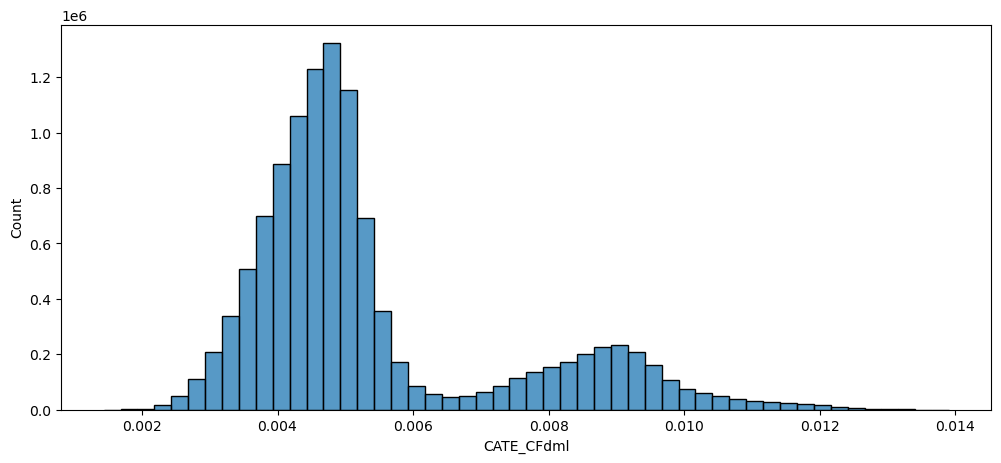

In [22]:
fig, ax =plt.subplots(1,1, figsize=(12,5))
sns.histplot(data=df_CATE, x='CATE_CFdml', bins=50)
fig.show()

## NonScientificDML

In [23]:
NSdml_models_t = pickle.load(open('/mnt/Production/PH_production/NSdml_models_t.pkl', 'rb'))

In [24]:
NSdml_model_final = pickle.load(open('/mnt/Production/PH_production/NSdml_model_final.pkl', 'rb'))

In [25]:
def ensamble_pred(df, models): 
    return np.mean([m.predict(df) for m in models], axis=0)

In [26]:
t_res = 1 - ensamble_pred(X, NSdml_models_t) #für Treatment = 1 vorhersagen

In [27]:
df_CATE['CATE_NSdml'] = NSdml_model_final.predict(X=X.assign(**{'T': t_res}))

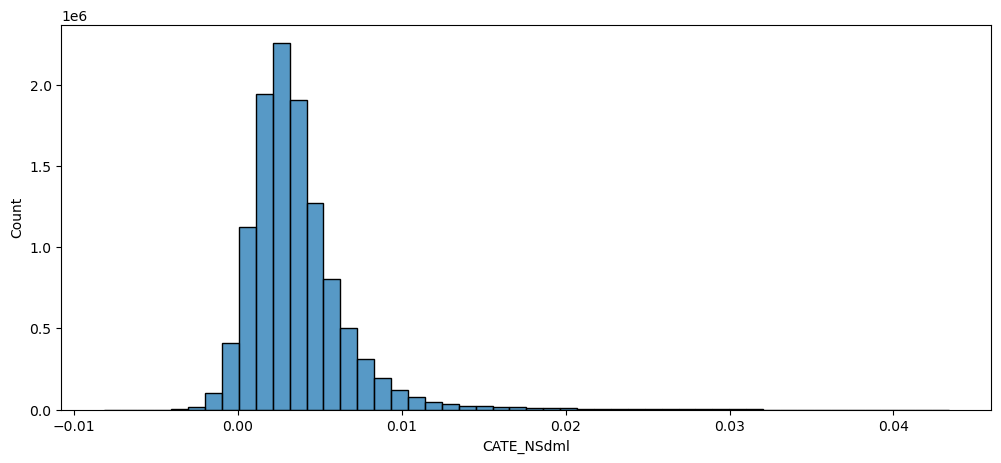

In [28]:
fig, ax =plt.subplots(1,1, figsize=(12,5))
sns.histplot(data=df_CATE, x='CATE_NSdml', bins=50)
fig.show()

## RLearner (NonParamDML)

In [29]:
Rlearn = pickle.load(open('/mnt/Production/PH_production/Rlearn.pkl', 'rb'))

In [30]:
df_CATE['CATE_Rlearn'] = predict_in_batches(X, Rlearn, 100000)

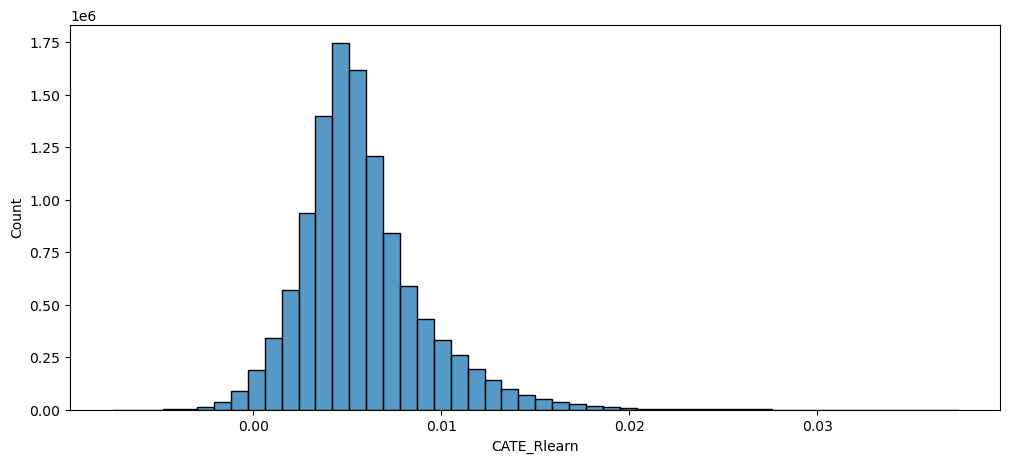

In [31]:
fig, ax =plt.subplots(1,1, figsize=(12,5))
sns.histplot(data=df_CATE, x='CATE_Rlearn', bins=50)
fig.show()

## DRLearner

In [32]:
DRlearn = pickle.load(open('/mnt/Production/PH_production/DRlearn.pkl', 'rb'))

In [33]:
df_CATE['CATE_DRlearn'] = predict_in_batches(X, DRlearn, 100000)

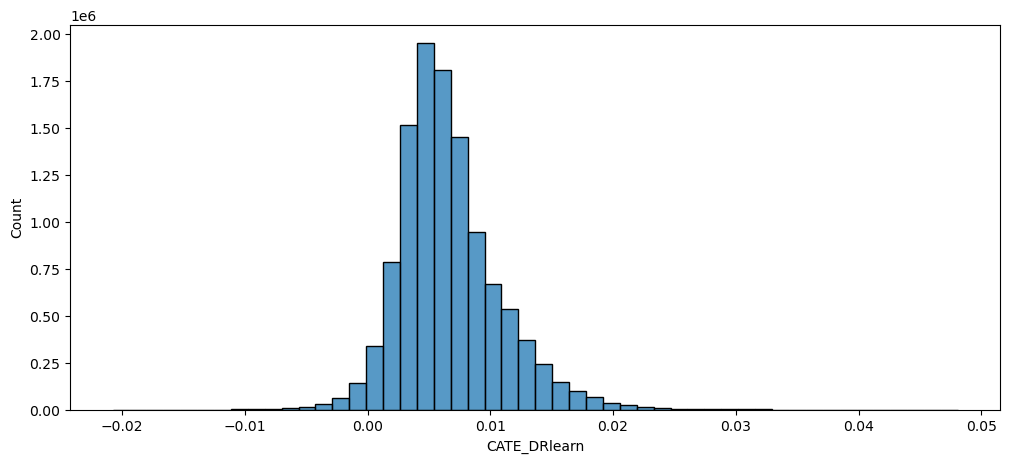

In [34]:
fig, ax =plt.subplots(1,1, figsize=(12,5))
sns.histplot(data=df_CATE, x='CATE_DRlearn', bins=50)
fig.show()

## XLearner

In [35]:
Xlearn = pickle.load(open('/mnt/Production/PH_production/Xlearn.pkl', 'rb'))

In [36]:
df_CATE['CATE_Xlearn'] = predict_in_batches(X, Xlearn, 100000)

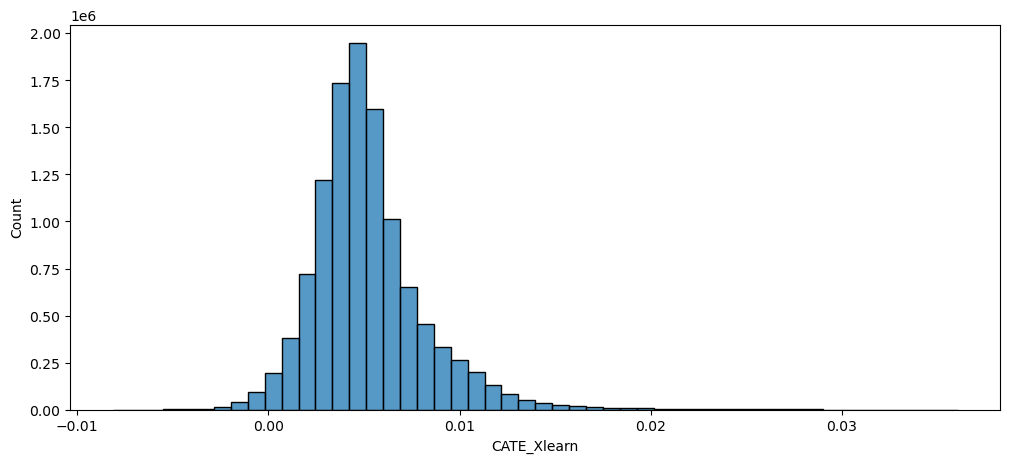

In [37]:
fig, ax =plt.subplots(1,1, figsize=(12,5))
sns.histplot(data=df_CATE, x='CATE_Xlearn', bins=50)
fig.show()

## TLearner

In [38]:
Tlearn = pickle.load(open('/mnt/Production/PH_production/Tlearn.pkl', 'rb'))

In [39]:
df_CATE['CATE_Tlearn'] = predict_in_batches(X, Tlearn, 100000)

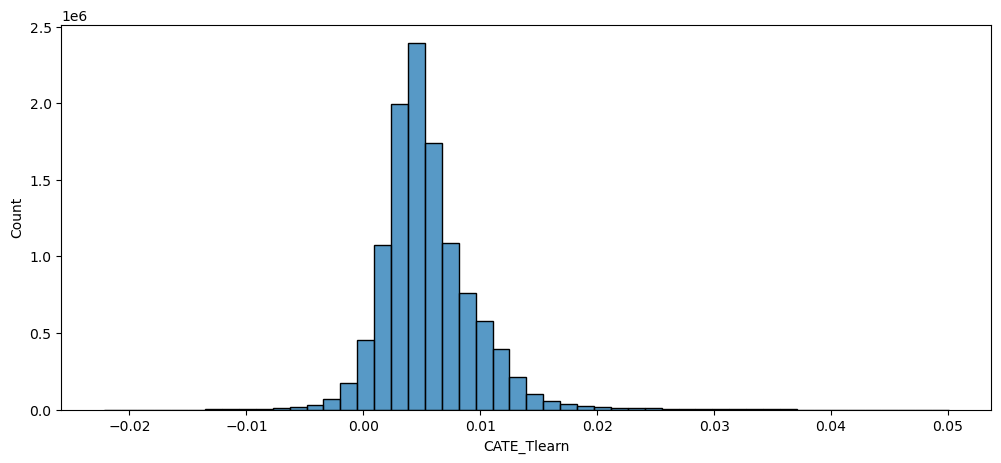

In [40]:
fig, ax =plt.subplots(1,1, figsize=(12,5))
sns.histplot(data=df_CATE, x='CATE_Tlearn', bins=50)
fig.show()

## SLearner

In [41]:
Slearn = pickle.load(open('/mnt/Production/PH_production/Slearn.pkl', 'rb'))

In [42]:
df_CATE['CATE_Slearn'] = predict_in_batches(X, Slearn, 100000)

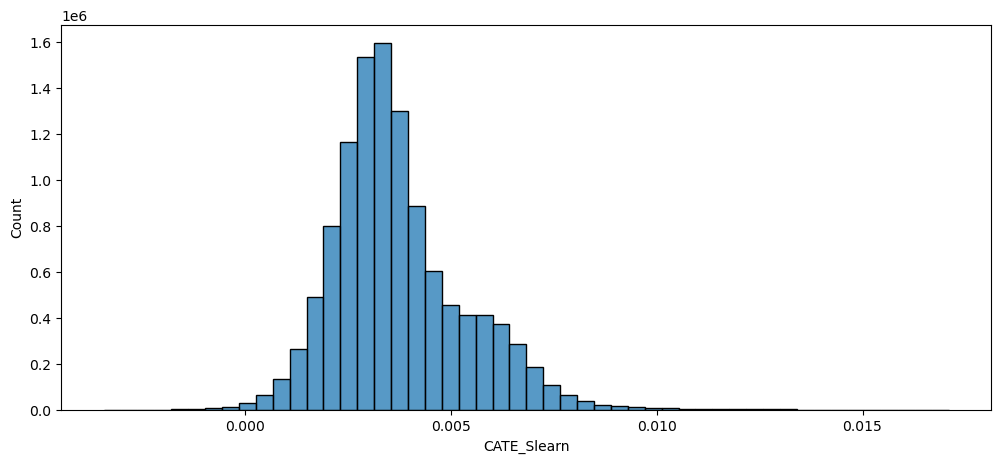

In [43]:
fig, ax =plt.subplots(1,1, figsize=(12,5))
sns.histplot(data=df_CATE, x='CATE_Slearn', bins=50)
fig.show()

## Ensemble Learning

In [44]:
df_CATE['CATE_ENSlearnM'] = (df_CATE['CATE_CFdml'] + df_CATE['CATE_NSdml'] + df_CATE['CATE_Rlearn'] + df_CATE['CATE_DRlearn'] + df_CATE['CATE_Xlearn'] + df_CATE['CATE_Tlearn'] + df_CATE['CATE_Slearn']) / 7

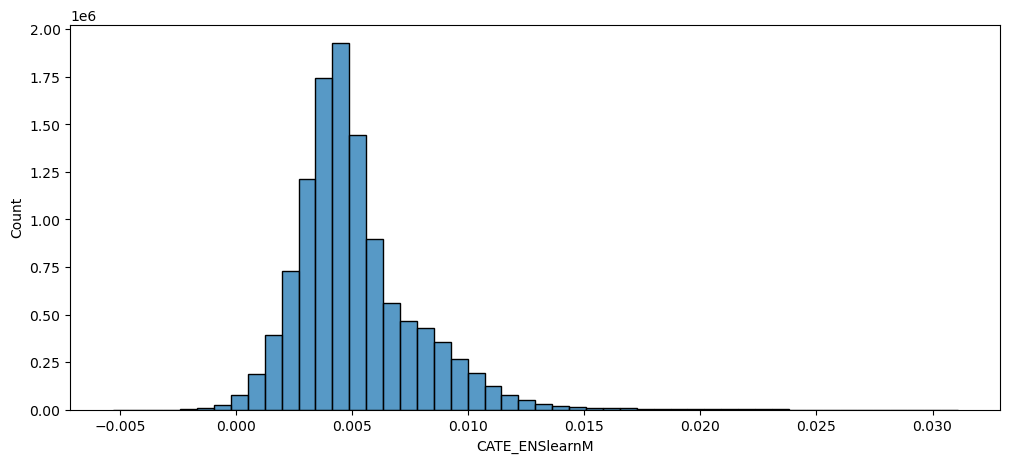

In [45]:
fig, ax =plt.subplots(1,1, figsize=(12,5))
sns.histplot(data=df_CATE, x='CATE_ENSlearnM', bins=50)
fig.show()

## Superlearner Ansatz

### ohne Metalearner

In [46]:
weights_Super = pickle.load(open('/mnt/Production/PH_production/weights_Super.pkl', 'rb'))

In [47]:
weights_Super

array([0.12944658, 0.12464064, 0.15218722, 0.1493991 , 0.15523394,
       0.19012558, 0.09896694])

In [48]:
#Anwendung
df_CATE['CATE_Super'] = (weights_Super[0] * df_CATE['CATE_CFdml'] + weights_Super[1] * df_CATE['CATE_NSdml'] + weights_Super[2] * df_CATE['CATE_Rlearn'] + weights_Super[3] * df_CATE['CATE_DRlearn'] + weights_Super[4] * df_CATE['CATE_Xlearn'] + weights_Super[5] * df_CATE['CATE_Tlearn'] + weights_Super[6] * df_CATE['CATE_Slearn']) / np.sum(weights_Super)

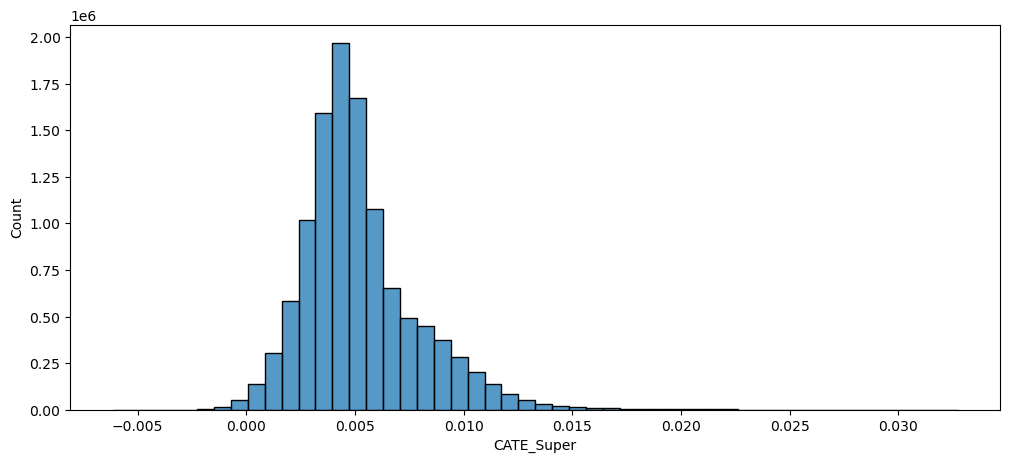

In [49]:
fig, ax =plt.subplots(1,1, figsize=(12,5))
sns.histplot(data=df_CATE, x='CATE_Super', bins=50)
fig.show()

### mit Metalearner

In [50]:
meta_learner = pickle.load(open('/mnt/Production/PH_production/meta_learner.pkl', 'rb'))

In [51]:
#Features vorbereiten
model1 = df_CATE['CATE_CFdml']
model2 = df_CATE['CATE_NSdml']
model3 = df_CATE['CATE_Rlearn']
model4 = df_CATE['CATE_DRlearn']
model5 = df_CATE['CATE_Xlearn']
model6 = df_CATE['CATE_Tlearn']
model7 = df_CATE['CATE_Slearn']


# Zusammensetzen der Features
meta_features = np.column_stack((model1, model2, model3, model4, model5, model6, model7))

# Anwenden des Meta-Learners
df_CATE['CATE_Supermeta'] = meta_learner.predict(meta_features)

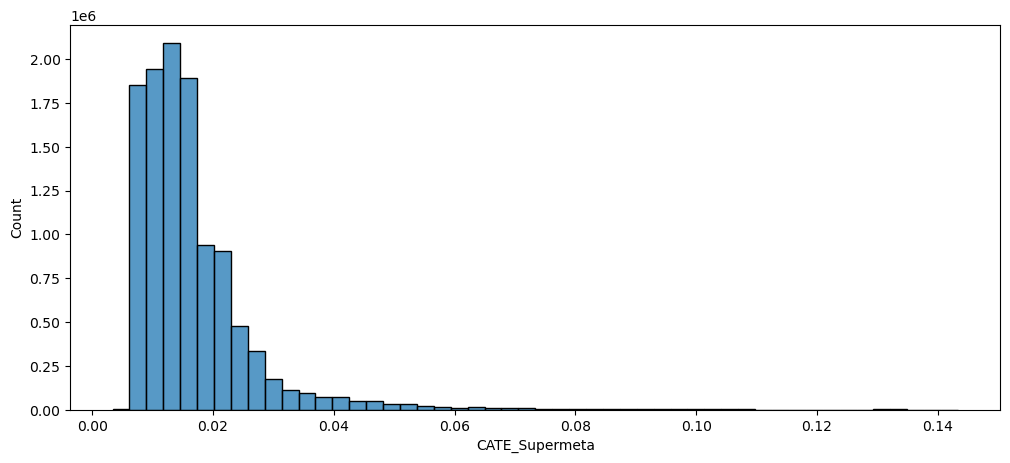

In [52]:
fig, ax =plt.subplots(1,1, figsize=(12,5))
sns.histplot(data=df_CATE, x='CATE_Supermeta', bins=50)
fig.show()

## Ensemble Learning with Superlearner and Ensemblelearner

In [53]:
df_CATE['CATE_ENSlearnS'] = (df_CATE['CATE_ENSlearnM'] + df_CATE['CATE_Super'] + df_CATE['CATE_Supermeta']) / 3

In [54]:
df_CATE

,CATE_CFdml,CATE_NSdml,CATE_Rlearn,CATE_DRlearn,CATE_Xlearn,CATE_Tlearn,CATE_Slearn,CATE_ENSlearnM,CATE_Super,CATE_Supermeta,CATE_ENSlearnS
0,0.008690,0.005265,0.011078,0.014168,0.006353,0.008763,0.006967,0.008755,0.008925,0.020779,0.012820
1,0.009128,0.006286,0.009100,0.014154,0.006721,0.007699,0.005249,0.008334,0.008491,0.022359,0.013062
2,0.004987,-0.000684,0.003445,0.004626,0.002996,0.004305,0.002195,0.003124,0.003276,0.010898,0.005766
3,0.009100,0.005130,0.010466,0.013746,0.009965,0.008757,0.005834,0.009000,0.009253,0.020779,0.013010
4,0.003977,0.003333,0.002337,0.004060,0.002176,0.003301,0.002667,0.003122,0.003122,0.012019,0.006087
...,...,...,...,...,...,...,...,...,...,...,...
11268077,0.011254,0.004413,0.010677,0.011136,0.009039,0.010503,0.007056,0.009154,0.009394,0.018351,0.012300
11268078,0.005057,0.001657,0.004062,0.003548,0.005180,0.005855,0.003020,0.004054,0.004226,0.014414,0.007565
11268079,0.005085,0.003097,0.005901,0.007909,0.006151,0.006573,0.004531,0.005607,0.005777,0.016622,0.009335
11268080,0.004839,0.000381,0.003415,0.002829,0.003824,0.005308,0.003057,0.003379,0.003522,0.012877,0.006593


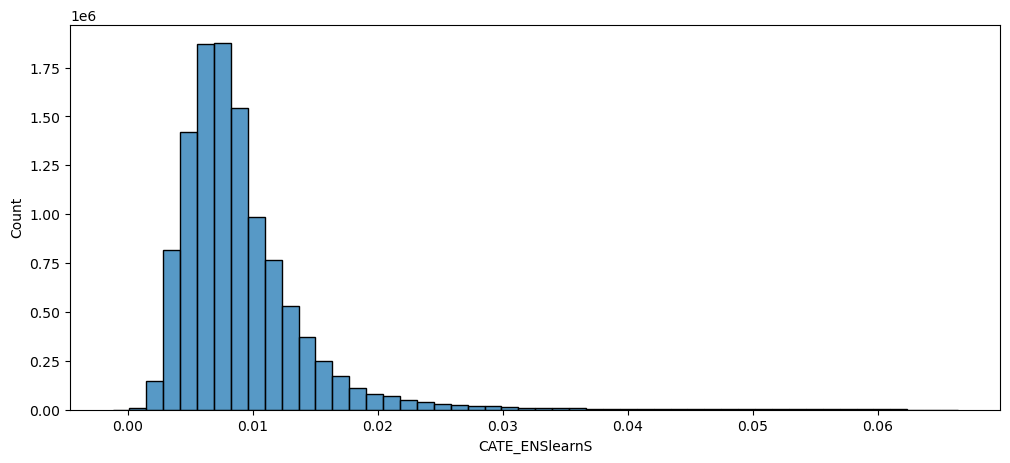

In [55]:
fig, ax =plt.subplots(1,1, figsize=(12,5))
sns.histplot(data=df_CATE, x='CATE_ENSlearnS', bins=50)
fig.show()

## Decision Tree on FINAL_MODEL

In [56]:
DT = pickle.load(open('/mnt/Production/PH_production/DT.pkl', 'rb'))

In [57]:
df_CATE['CATE_DT'] = DT.predict(X)

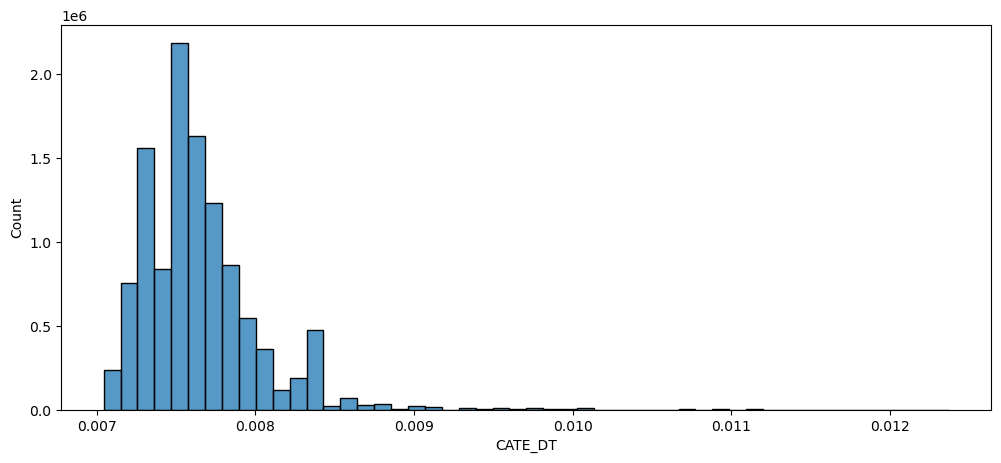

In [58]:
fig, ax =plt.subplots(1,1, figsize=(12,5))
sns.histplot(data=df_CATE, x='CATE_DT', bins=50)
fig.show()

# Ergebnisse zurückschreiben

In [59]:
df_CATE_SAS = pd.concat([df_CATE[f'CATE_{FINAL_MODEL}'], df_CATE['CATE_DT'], I], axis=1)
df_CATE_SAS = df_CATE_SAS.rename(columns={f'CATE_{FINAL_MODEL}': 'SCORE_P'})
df_CATE_SAS = df_CATE_SAS.rename(columns={'CATE_DT': 'SCORE_B'})
df_CATE_SAS['SCORE_TYP'] = 'MO_SCORE_20_INVESTBER'
df_CATE_SAS['VALID_TO'] = '31DEC9999'
df_CATE_SAS['SCORE_VERFAHREN'] = 'kausal'
df_CATE_SAS['TIMESTAMP'] = TIMESTAMP

In [60]:
df_CATE_SAS = df_CATE_SAS[['PARTNER_ID_V', 'GESELLSCHAFT_FS', 'SCORE_TYP', 'VALID_TO', 'SCORE_P', 'SCORE_B', 'SCORE_VERFAHREN', 'TIMESTAMP']]

In [61]:
df_CATE_SAS

,PARTNER_ID_V,GESELLSCHAFT_FS,SCORE_TYP,VALID_TO,SCORE_P,SCORE_B,SCORE_VERFAHREN,TIMESTAMP
0,12,HC,MO_SCORE_20_INVESTBER,31DEC9999,0.012820,0.008306,kausal,2025-142
1,35,HUK24,MO_SCORE_20_INVESTBER,31DEC9999,0.013062,0.008306,kausal,2025-142
2,51,HCA,MO_SCORE_20_INVESTBER,31DEC9999,0.005766,0.007287,kausal,2025-142
3,90,HUK24,MO_SCORE_20_INVESTBER,31DEC9999,0.013010,0.007963,kausal,2025-142
4,104,HC,MO_SCORE_20_INVESTBER,31DEC9999,0.006087,0.007581,kausal,2025-142
...,...,...,...,...,...,...,...,...
11268077,145424208,HC,MO_SCORE_20_INVESTBER,31DEC9999,0.012300,0.008135,kausal,2025-142
11268078,145424213,HUK24,MO_SCORE_20_INVESTBER,31DEC9999,0.007565,0.007326,kausal,2025-142
11268079,145424218,HCA,MO_SCORE_20_INVESTBER,31DEC9999,0.009335,0.007564,kausal,2025-142
11268080,145424222,HUK24,MO_SCORE_20_INVESTBER,31DEC9999,0.006593,0.007326,kausal,2025-142


In [62]:
scaler = StandardScaler()

In [63]:
df_CATE_SAS[['SCORE_P', 'SCORE_B']] = scaler.fit_transform(df_CATE_SAS[['SCORE_P', 'SCORE_B']])
df_CATE_SAS[['SCORE_P', 'SCORE_B']] = df_CATE_SAS[['SCORE_P', 'SCORE_B']].round(4)
df_CATE_SAS[['SCORE_P', 'SCORE_B']] = df_CATE_SAS[['SCORE_P', 'SCORE_B']] + 100

In [64]:
df_CATE_SAS

,PARTNER_ID_V,GESELLSCHAFT_FS,SCORE_TYP,VALID_TO,SCORE_P,SCORE_B,SCORE_VERFAHREN,TIMESTAMP
0,12,HC,MO_SCORE_20_INVESTBER,31DEC9999,100.7850,101.7549,kausal,2025-142
1,35,HUK24,MO_SCORE_20_INVESTBER,31DEC9999,100.8338,101.7549,kausal,2025-142
2,51,HCA,MO_SCORE_20_INVESTBER,31DEC9999,99.3629,99.0528,kausal,2025-142
3,90,HUK24,MO_SCORE_20_INVESTBER,31DEC9999,100.8235,100.8463,kausal,2025-142
4,104,HC,MO_SCORE_20_INVESTBER,31DEC9999,99.4276,99.8322,kausal,2025-142
...,...,...,...,...,...,...,...,...
11268077,145424208,HC,MO_SCORE_20_INVESTBER,31DEC9999,100.6801,101.3028,kausal,2025-142
11268078,145424213,HUK24,MO_SCORE_20_INVESTBER,31DEC9999,99.7254,99.1566,kausal,2025-142
11268079,145424218,HCA,MO_SCORE_20_INVESTBER,31DEC9999,100.0824,99.7877,kausal,2025-142
11268080,145424222,HUK24,MO_SCORE_20_INVESTBER,31DEC9999,99.5295,99.1566,kausal,2025-142


In [65]:
# Speichern des DataFrames als SAS-Datei
pyreadstat.write_xport(df_CATE_SAS, TARGET_PATH, column_labels=df_CATE_SAS.columns.tolist(), table_name='kau_ph', file_format_version=5)

In [66]:
et = time.time()

In [67]:
elapsed_time= (et - st) / 60
print('elapsed time:', elapsed_time)

elapsed time: 91.0809941013654
